# Imports .. 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


# DEVICE


In [3]:


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu



# LOAD DATA


In [4]:



data = np.load("10_DATA_TRPCAGE.npy")

print("Data shape:", data.shape)

Data shape: (50000, 38)



# NORMALIZATION


In [5]:

# Not needed here as data is already normalized 

#data_mean = data.mean(axis=0)
#data_std  = data.std(axis=0) + 1e-8

#data_norm = (data - data_mean) / data_std


# Convert and load the data into tensors 


In [7]:


tensor_data = torch.tensor(data, dtype=torch.float32)

dataset = TensorDataset(tensor_data)

loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True
)



# HYPERPARAMETERS


In [8]:
input_dim  = data.shape[1]
latent_dim = 2

epochs = 200
lr = 1e-3


# AUTOENCODER


In [9]:


class AutoEncoder(nn.Module):

    def __init__(self, input_dim, latent_dim):

        super().__init__()

        # ====================================================
        # ENCODER
        # ====================================================

        self.encoder = nn.Sequential(

            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, latent_dim)

        )

        # ====================================================
        # DECODER
        # ====================================================

        self.decoder = nn.Sequential(

            nn.Linear(latent_dim, 64),
            nn.ReLU(),

            nn.Linear(64, 128),
            nn.ReLU(),

            nn.Linear(128, input_dim)

        )

    def forward(self, x):

        z = self.encoder(x)

        xhat = self.decoder(z)

        return xhat, z



# Initialize the  MODEL and Optimizer


In [11]:


AE = AutoEncoder(input_dim, latent_dim).to(device)


optimizer = torch.optim.Adam(AE.parameters(), lr=lr)

# Loss 

In [10]:
criterion = nn.MSELoss()

# Training ...

In [12]:

ae_losses = []

print("\nTraining AutoEncoder...\n")

for epoch in range(epochs):

    total_loss = 0.0

    for batch in loader:

        x = batch[0].to(device)

        xhat, z = AE(x)

        loss = criterion(xhat, x)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)

    ae_losses.append(avg_loss)

    print(f"AE Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")




Training AutoEncoder...

AE Epoch [1/200] Loss: 1.527648
AE Epoch [2/200] Loss: 1.203179
AE Epoch [3/200] Loss: 1.159859
AE Epoch [4/200] Loss: 1.147693
AE Epoch [5/200] Loss: 1.138454
AE Epoch [6/200] Loss: 1.126831
AE Epoch [7/200] Loss: 1.112601
AE Epoch [8/200] Loss: 1.097350
AE Epoch [9/200] Loss: 1.081475
AE Epoch [10/200] Loss: 1.065812
AE Epoch [11/200] Loss: 1.047925
AE Epoch [12/200] Loss: 1.036591
AE Epoch [13/200] Loss: 1.028071
AE Epoch [14/200] Loss: 1.021579
AE Epoch [15/200] Loss: 1.015442
AE Epoch [16/200] Loss: 1.010467
AE Epoch [17/200] Loss: 1.007153
AE Epoch [18/200] Loss: 1.003145
AE Epoch [19/200] Loss: 0.999857
AE Epoch [20/200] Loss: 0.995833
AE Epoch [21/200] Loss: 0.990806
AE Epoch [22/200] Loss: 0.983254
AE Epoch [23/200] Loss: 0.977354
AE Epoch [24/200] Loss: 0.971351
AE Epoch [25/200] Loss: 0.966427
AE Epoch [26/200] Loss: 0.962997
AE Epoch [27/200] Loss: 0.959530
AE Epoch [28/200] Loss: 0.955502
AE Epoch [29/200] Loss: 0.953364
AE Epoch [30/200] Loss: 0.


# LOSS CURVES


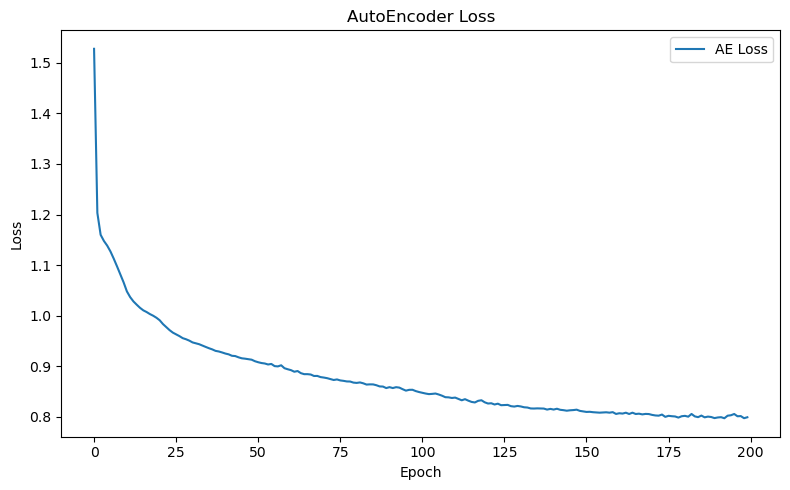

In [15]:

np.save("ae_loss.npy",ae_losses )

plt.figure(figsize=(8,5))

plt.plot(ae_losses, label="AE Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("AutoEncoder Loss")

plt.legend()

plt.tight_layout()

plt.savefig("ae_loss.png", dpi=300)


# SAVE AE MODEL



In [16]:

torch.save(AE.state_dict(), "autoencoder.pt")

print("\nAutoEncoder saved.")


AutoEncoder saved.



# LATENT REPRESENTATION


In [17]:


AE.eval()

latent_ae = []

with torch.no_grad():

    for batch in loader:

        x = batch[0].to(device)

        _, z = AE(x)

        latent_ae.append(z.cpu().numpy())

latent_ae = np.concatenate(latent_ae, axis=0)


# PLOT AE LATENT SPACE


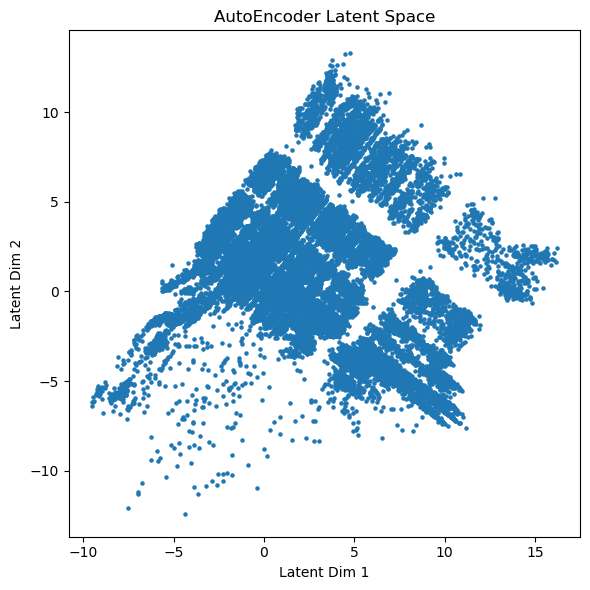

In [18]:


plt.figure(figsize=(6,6))

plt.scatter(
    latent_ae[:,0],
    latent_ae[:,1],
    s=5
)

plt.xlabel("Latent Dim 1")
plt.ylabel("Latent Dim 2")

plt.title("AutoEncoder Latent Space")

plt.tight_layout()

plt.savefig("ae_latent.png", dpi=300)
